# １章６節１項 合成開口アルゴリズム

## 概要
ストルト補完の実装によってK-空間の変化を可視化します。

## 使用データ

| 項目 | 使用データなし |
| ---- | ---- | 

In [ ]:
import os
import numpy as np
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

PATH_OUTPUT = os.path.join('output', '1_6_1')
os.makedirs(PATH_OUTPUT, exist_ok=True)

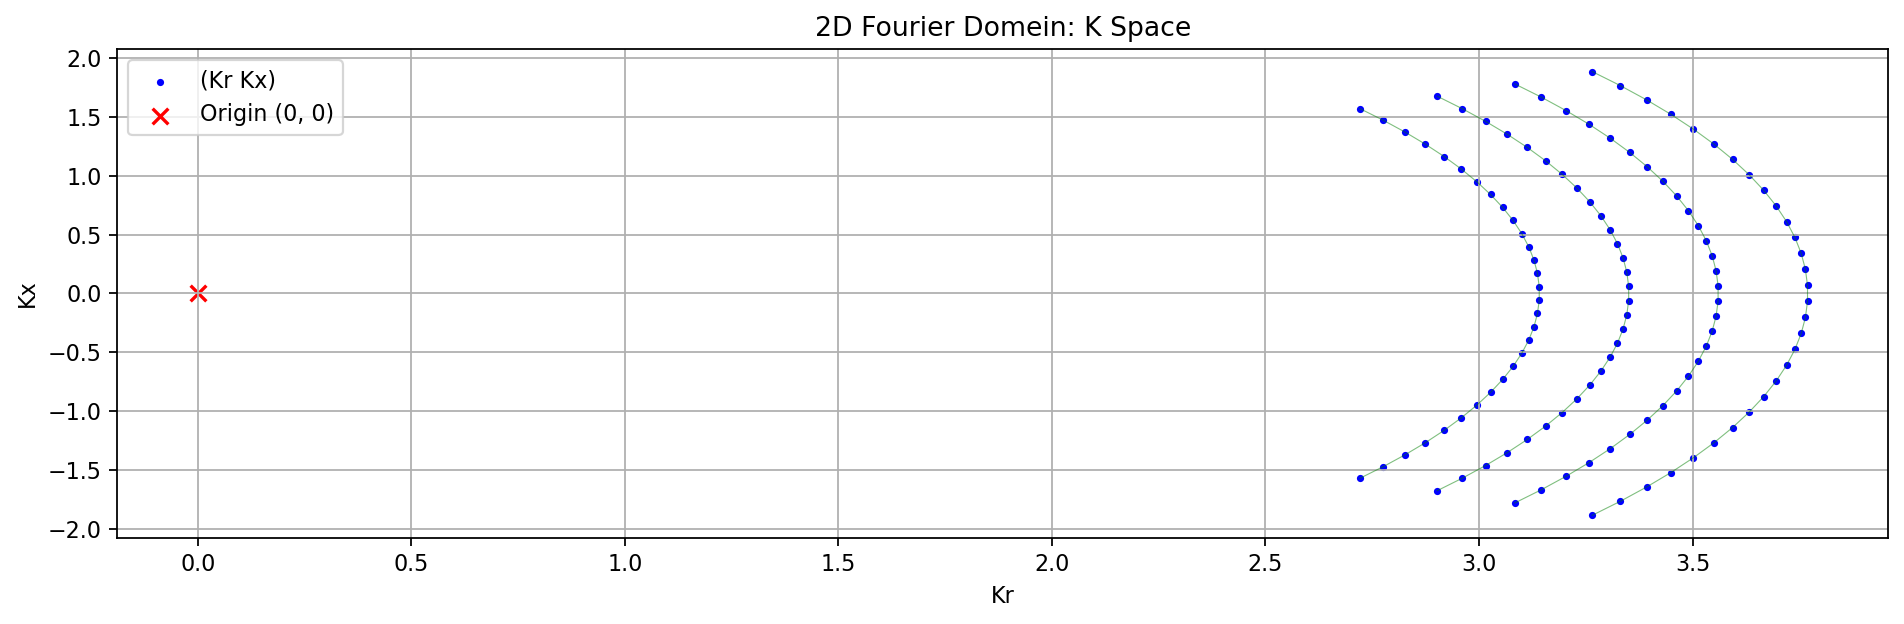

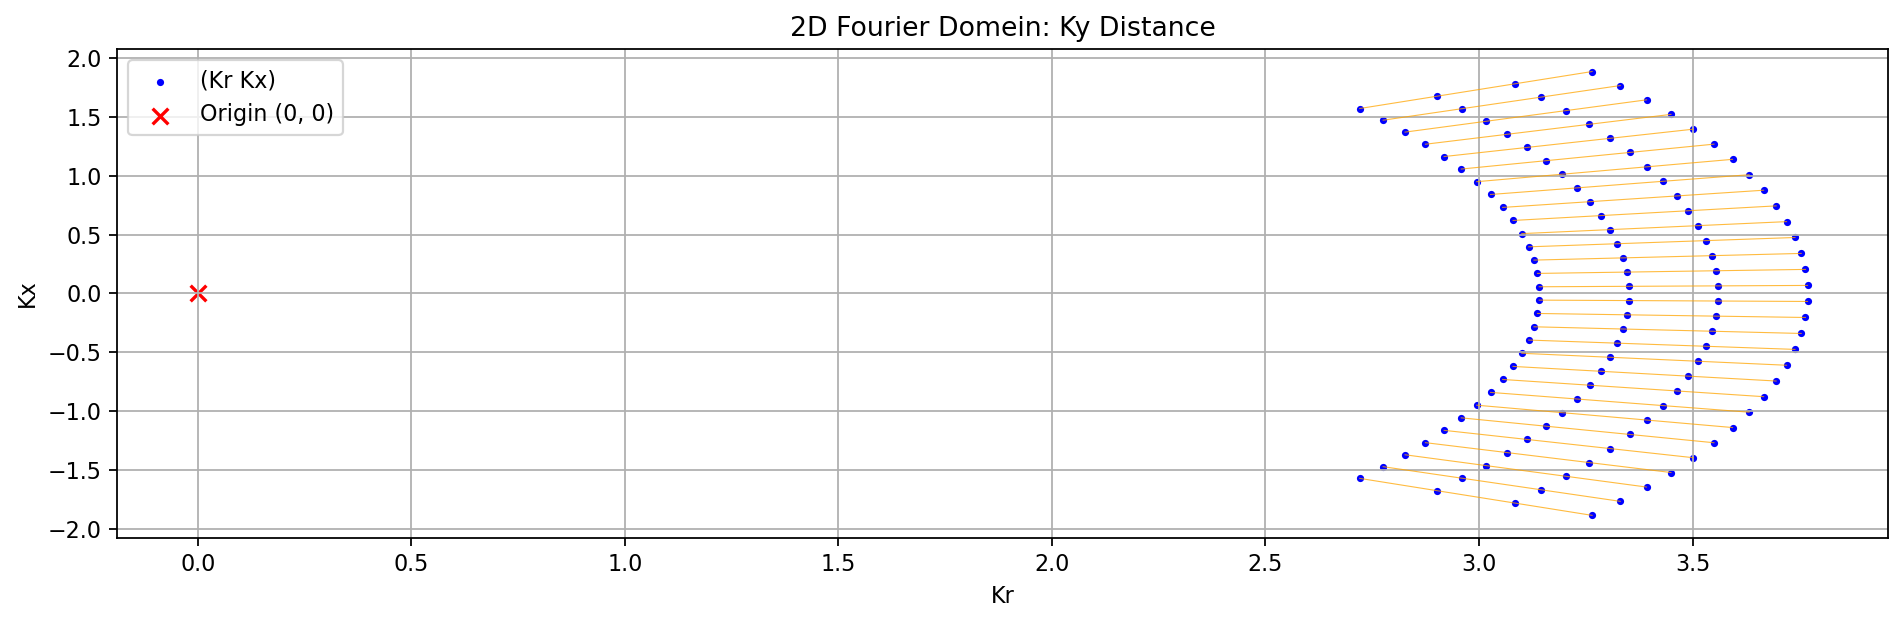

In [2]:
# sample data
NUM_PULSE = 4
NUM_SAMPLE = 30

pulse_range = np.linspace(np.pi/3, np.pi*2/3, NUM_SAMPLE)
omega_s = np.linspace(np.pi, np.pi * 1.2, NUM_PULSE)

# Cartesian to Polar
k_rx = np.stack([
 omega * np.array([np.sin(pulse_range), np.cos(pulse_range)])
for omega in omega_s], axis=0
)

# plot
plt.figure(figsize=(12, 4), dpi=160, facecolor='w', edgecolor='k')
plt.title('2D Fourier Domein: K Space')
plt.scatter(k_rx[:, 0], k_rx[:, 1], c='b', marker='o', label='(Kr Kx)', s=5)
for k_ in k_rx:
    plt.plot(k_[0], k_[1], c='g', linestyle='-', linewidth=0.5, alpha=0.5)
plt.scatter(0, 0, c='r', marker='x', label='Origin (0, 0)', s=50)
plt.grid()
plt.xlabel('Kr')
plt.ylabel('Kx')
plt.legend()
plt.tight_layout()
plt.savefig(f'{PATH_OUTPUT}/K-space_xr_sample{NUM_SAMPLE}_pulse{NUM_PULSE}.png')
plt.show();plt.clf();plt.close()

# plot
plt.figure(figsize=(12, 4), dpi=160, facecolor='w', edgecolor='k')
plt.title('2D Fourier Domein: Ky Distance')
plt.scatter(k_rx[:, 0], k_rx[:, 1], c='b', marker='o', label='(Kr Kx)', s=5)
plt.plot(k_rx[:, 0], k_rx[:, 1], c='orange', linestyle='-', linewidth=0.5, alpha=0.75 )
plt.scatter(0, 0, c='r', marker='x', label='Origin (0, 0)', s=50)
plt.grid()
plt.xlabel('Kr')
plt.ylabel('Kx')
plt.legend()
plt.tight_layout()
plt.savefig(f'{PATH_OUTPUT}/K-space_ky-distance_sample{NUM_SAMPLE}_pulse{NUM_PULSE}.png')
plt.show();plt.clf();plt.close()

In [3]:
def stolt_interpolation(kr, kx, omega):
    # calculate ky distance
    ky = (kr**2 - kx**2) ** 0.5
    signature = np.sign(kx)
    
    # interpolate
    func_omega = interp1d(ky, omega, fill_value="extrapolate")
    
    # normalize 
    kx_norm = (func_omega(kr) / (kr) - 1) 
    return kx_norm * signature

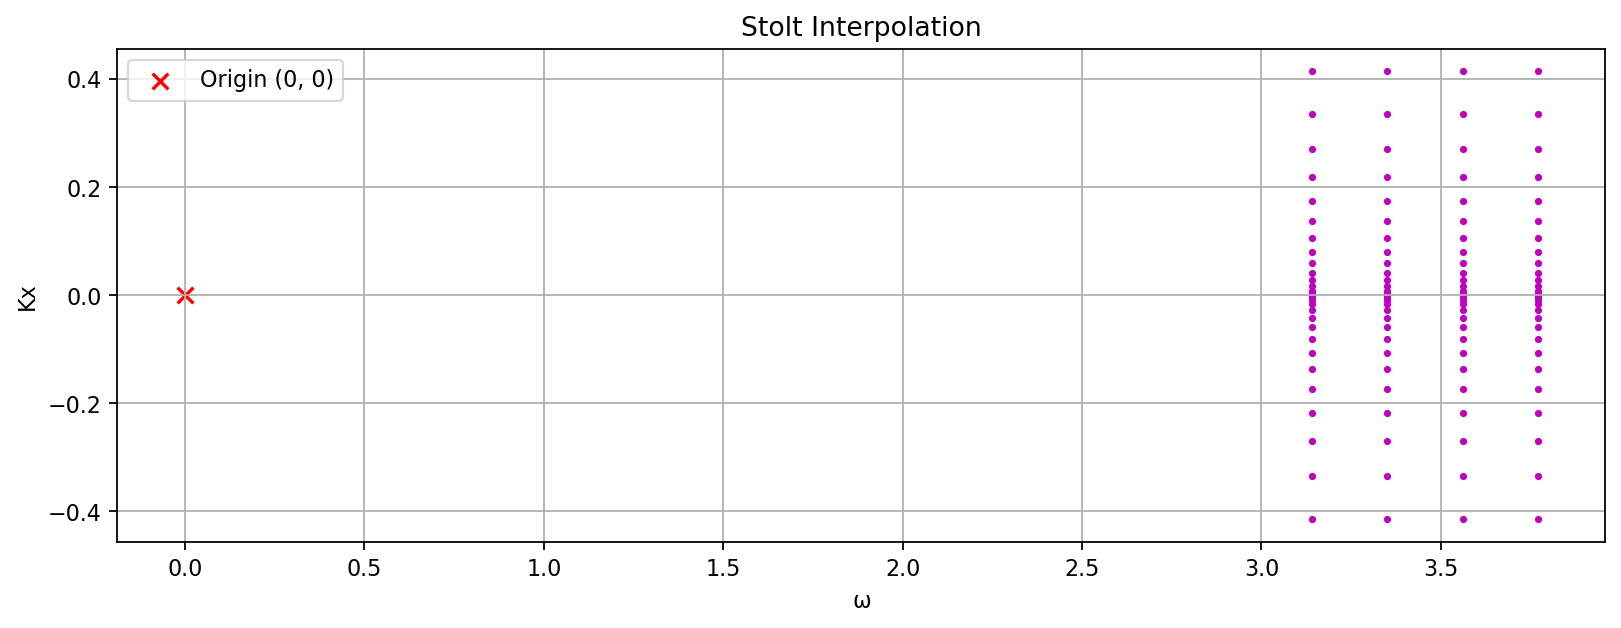

In [4]:
stolt_interpolated_kx = np.stack([
        stolt_interpolation(k_rx[:, 0, i_], k_rx[:, 1, i_], omega_s)
        for i_, rx in enumerate(k_rx[0,0,])
    ], axis=1)

omega_sample = np.stack([omega_s] * stolt_interpolated_kx.shape[1],axis=1)
# plot
plt.figure(figsize=(12, 4), dpi=160, facecolor='w', edgecolor='k')

plt.title('Stolt Interpolation')
plt.scatter(0, 0, c='r', marker='x', label='Origin (0, 0)', s=50)
for _i, _omera in enumerate(omega_s):
    plt.scatter(omega_sample[_i], stolt_interpolated_kx[_i], 
                c='m', marker='o', s=5, )
plt.grid()
plt.xlabel('ω')
plt.ylabel('Kx')
plt.legend()
plt.savefig(f'{PATH_OUTPUT}/stolt_interpolation_sample{NUM_SAMPLE}_pulse{NUM_PULSE}.png')
plt.show();plt.clf();plt.close()

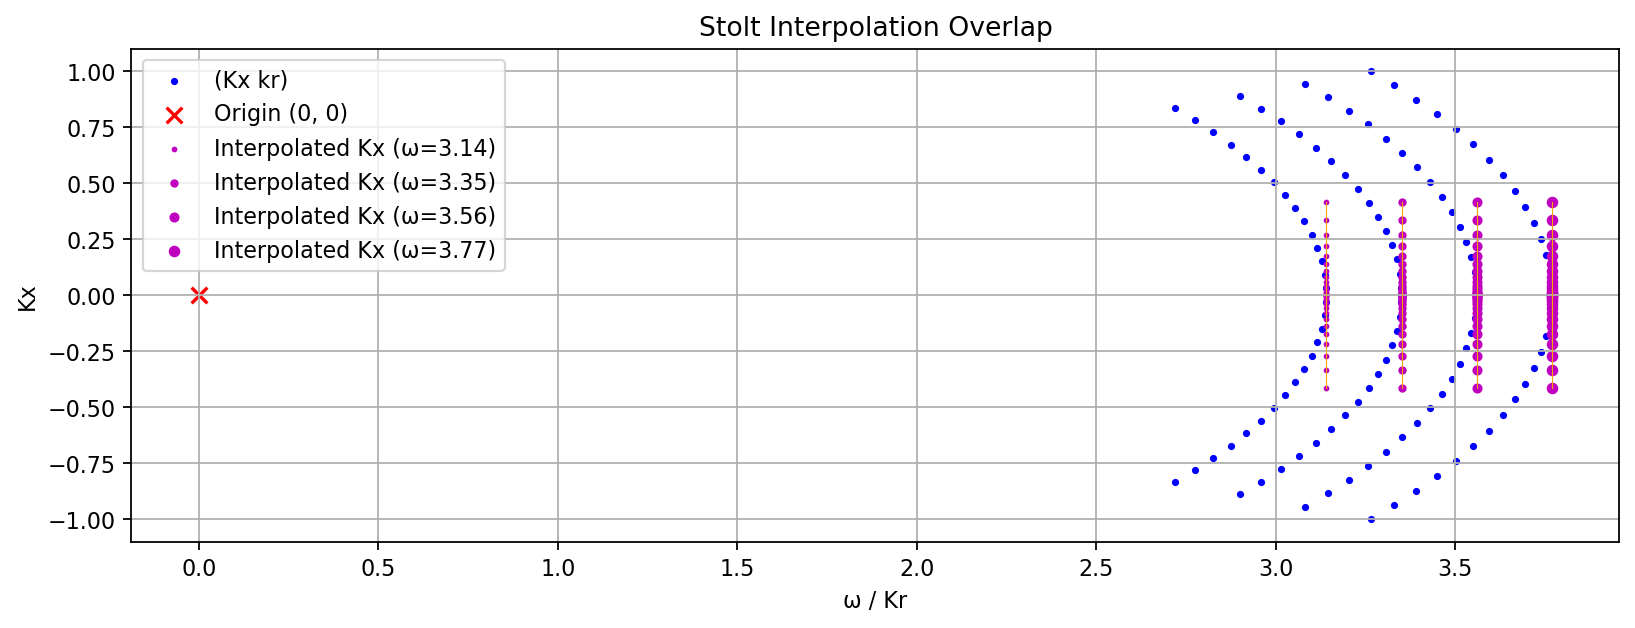

In [10]:
# plot
plt.figure(figsize=(12, 4), dpi=160, facecolor='w', edgecolor='k')
plt.title('Stolt Interpolation Overlap')
plt.scatter(k_rx[:, 0], k_rx[:, 1]/k_rx[:, 1].max(), c='b', marker='o', label='(Kx kr)', s=5)
plt.scatter(0, 0, c='r', marker='x', label='Origin (0, 0)', s=50)
for _i, _omera in enumerate(omega_s):
    plt.scatter(omega_sample[_i], stolt_interpolated_kx[_i], 
                c='m', marker='o', s=5*(_i+0.5), 
                label=f'Interpolated Kx (ω={_omera:.2f})'
                )
    plt.plot(omega_sample[_i], stolt_interpolated_kx[_i], c='orange', linestyle='-', linewidth=0.5, )
plt.grid()
plt.xlabel('ω / Kr')
plt.ylabel('Kx')
plt.legend()
plt.savefig(f'{PATH_OUTPUT}/stolt_interpolation_overlap_sample{NUM_SAMPLE}_pulse{NUM_PULSE}.png')
plt.show();plt.clf();plt.close()

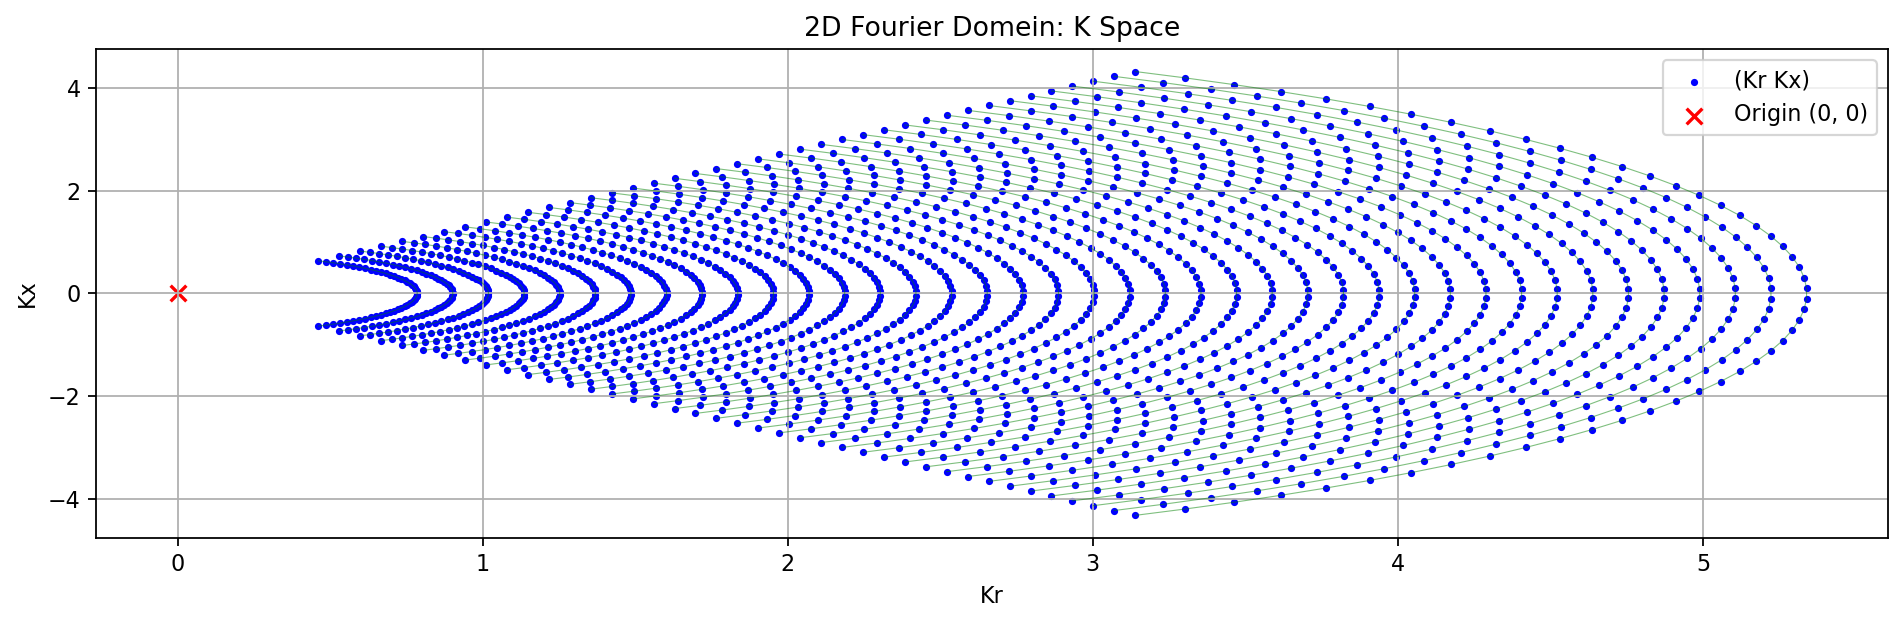

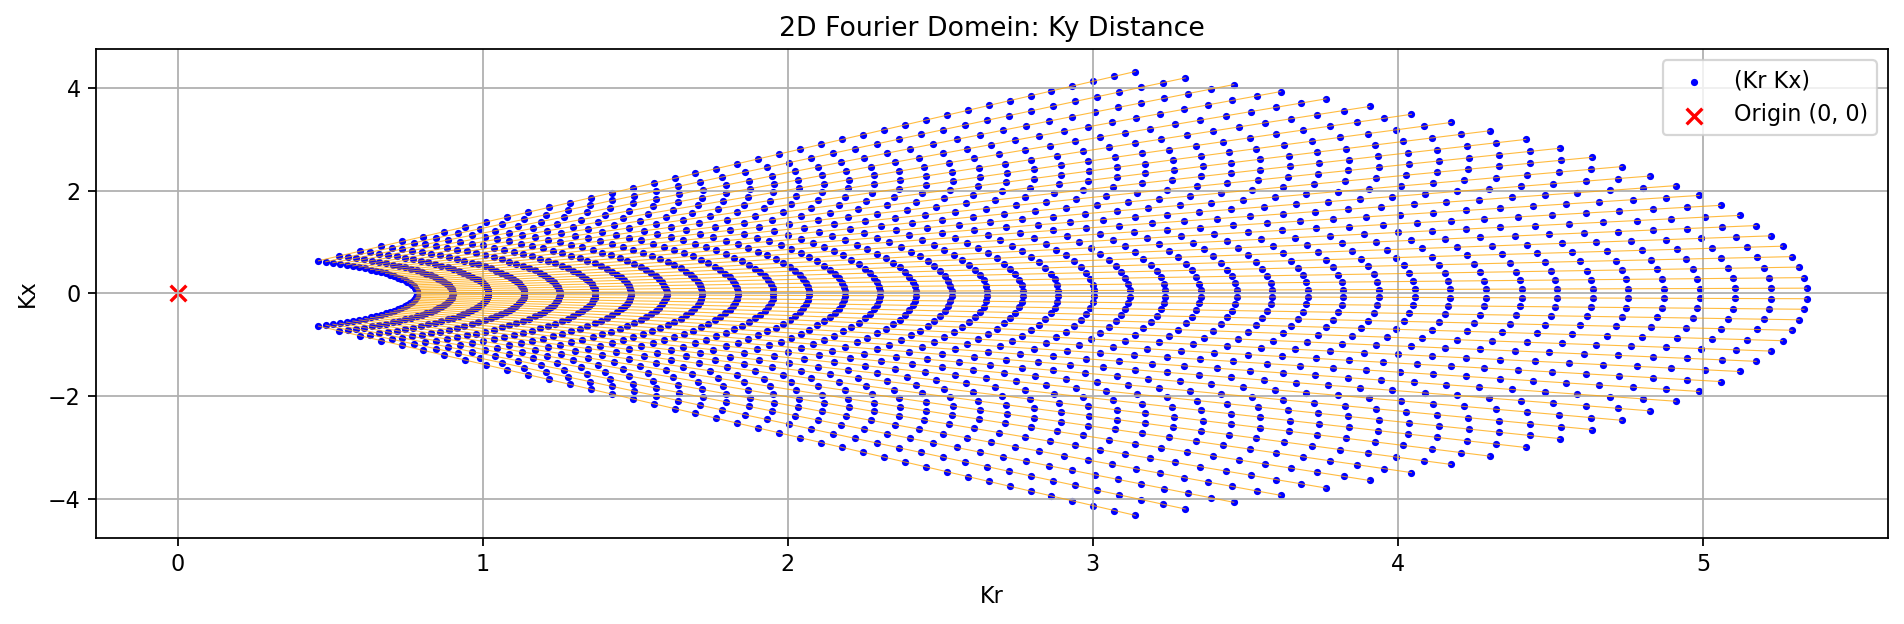

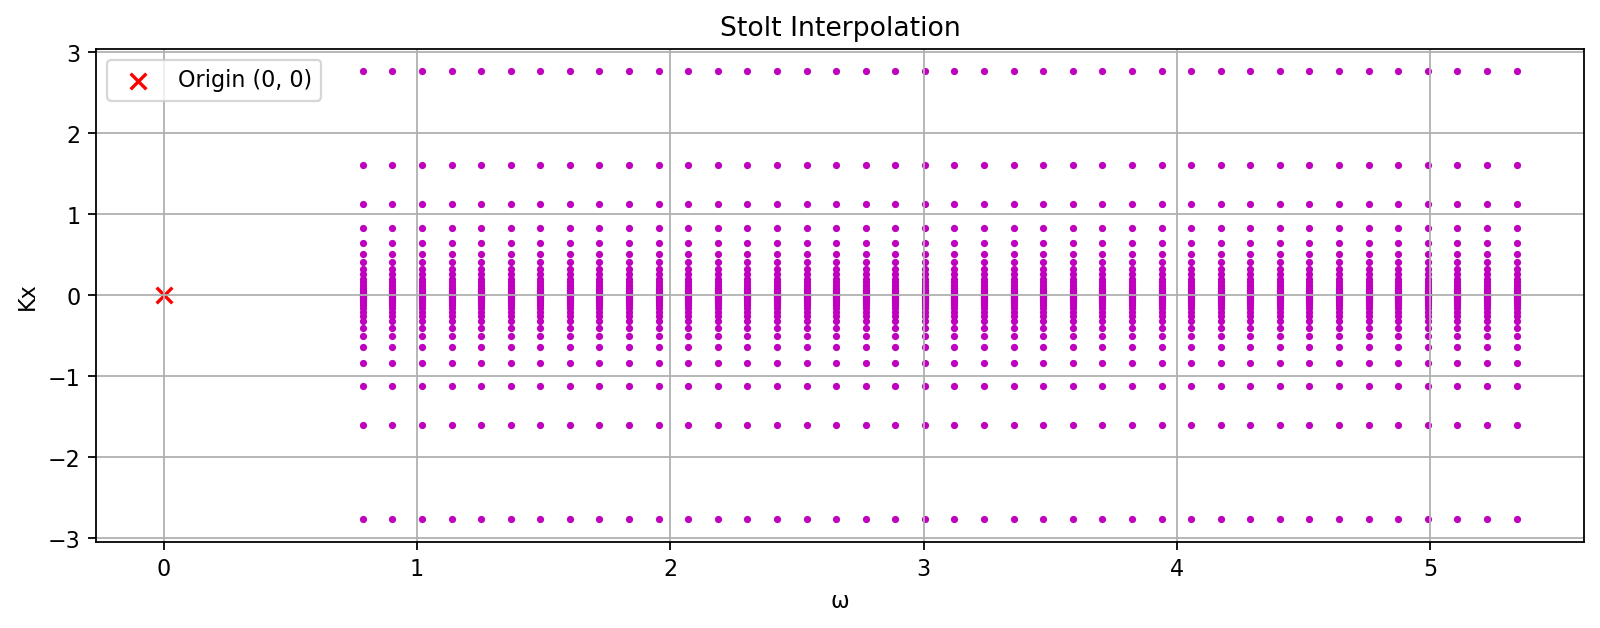

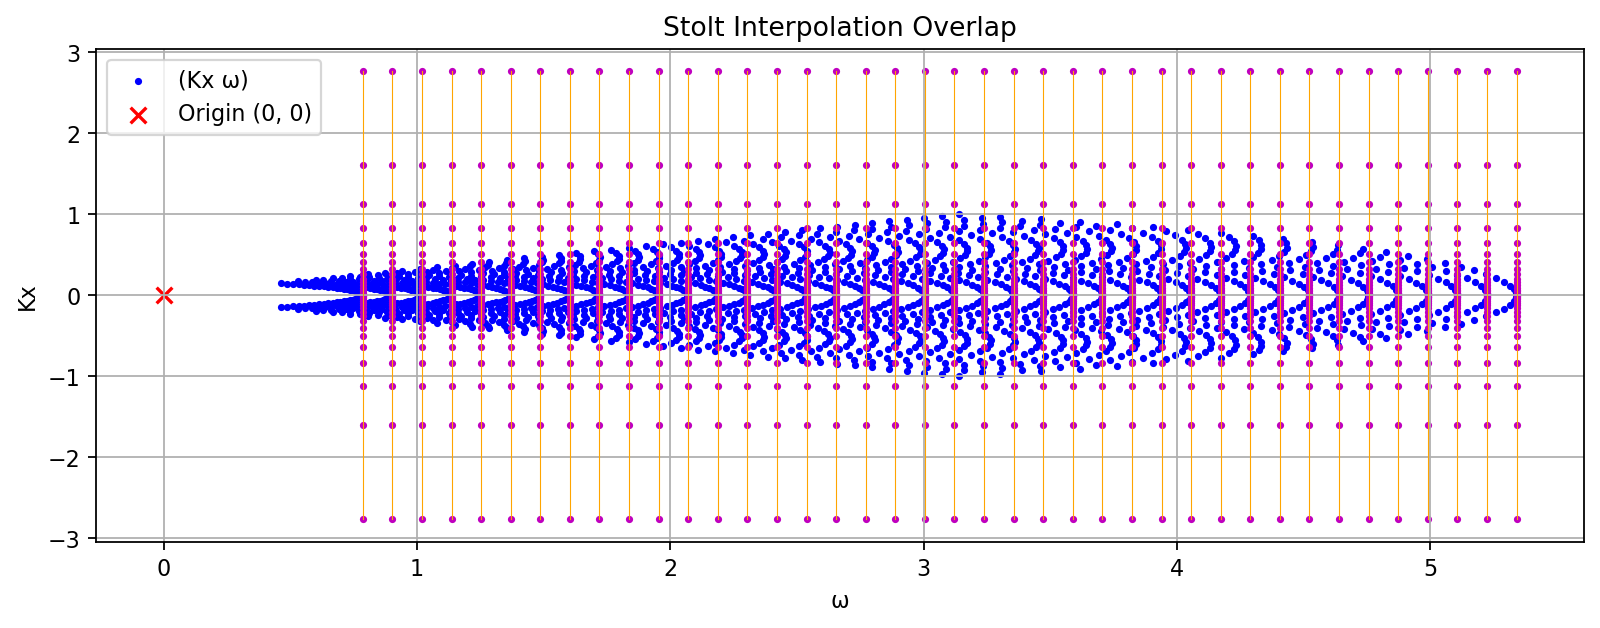

In [7]:
# sample data
NUM_PULSE = 40
NUM_SAMPLE = 50

pulse_range = np.linspace(np.pi/5, np.pi*4/5, NUM_SAMPLE)
omega_s = np.linspace(np.pi/4, np.pi * 1.7, NUM_PULSE)

# Cartesian to Polar
k_rx = np.stack([
 omega * np.array([np.sin(pulse_range), np.cos(pulse_range)])
for omega in omega_s], axis=0
)

# plot
plt.figure(figsize=(12, 4), dpi=160, facecolor='w', edgecolor='k')
plt.title('2D Fourier Domein: K Space')
plt.scatter(k_rx[:, 0], k_rx[:, 1], c='b', marker='o', label='(Kr Kx)', s=5)
for k_ in k_rx:
    plt.plot(k_[0], k_[1], c='g', linestyle='-', linewidth=0.5, alpha=0.5)
plt.scatter(0, 0, c='r', marker='x', label='Origin (0, 0)', s=50)
plt.grid()
plt.xlabel('Kr')
plt.ylabel('Kx')
plt.legend()
plt.tight_layout()
plt.savefig(f'{PATH_OUTPUT}/K-space_xr_sample{NUM_SAMPLE}_pulse{NUM_PULSE}.png')
plt.show();plt.clf();plt.close()

# plot
plt.figure(figsize=(12, 4), dpi=160, facecolor='w', edgecolor='k')
plt.title('2D Fourier Domein: Ky Distance')
plt.scatter(k_rx[:, 0], k_rx[:, 1], c='b', marker='o', label='(Kr Kx)', s=5)
plt.plot(k_rx[:, 0], k_rx[:, 1], c='orange', linestyle='-', linewidth=0.5, alpha=0.75 )
plt.scatter(0, 0, c='r', marker='x', label='Origin (0, 0)', s=50)
plt.grid()
plt.xlabel('Kr')
plt.ylabel('Kx')
plt.legend()
plt.tight_layout()
plt.savefig(f'{PATH_OUTPUT}/K-space_ky-distance_sample{NUM_SAMPLE}_pulse{NUM_PULSE}.png')
plt.show();plt.clf();plt.close()

stolt_interpolated_kx = np.stack([
        stolt_interpolation(k_rx[:, 0, i_], k_rx[:, 1, i_], omega_s)
        for i_, rx in enumerate(k_rx[0,0,])
    ], axis=1)

omega_sample = np.stack(
    [omega_s] * stolt_interpolated_kx.shape[1],
    axis=1)

# plot
plt.figure(figsize=(12, 4), dpi=160, facecolor='w', edgecolor='k')

plt.title('Stolt Interpolation')
plt.scatter(0, 0, c='r', marker='x', label='Origin (0, 0)', s=50)
for _i, _omera in enumerate(omega_s):
    plt.scatter(omega_sample[_i], stolt_interpolated_kx[_i], 
                c='m', marker='o', s=5, # label=f'Interpolated Kx (ω={_omera})'
    )
plt.grid()
plt.xlabel('ω')
plt.ylabel('Kx')
plt.legend()
plt.savefig(f'{PATH_OUTPUT}/stolt_interpolation_sample{NUM_SAMPLE}_pulse{NUM_PULSE}.png')
plt.show();plt.clf();plt.close()

# plot
plt.figure(figsize=(12, 4), dpi=160, facecolor='w', edgecolor='k')
plt.title('Stolt Interpolation Overlap')
plt.scatter(k_rx[:, 0], k_rx[:, 1]/k_rx[:, 1].max(), c='b', marker='o', label='(Kx ω)', s=5)
plt.scatter(0, 0, c='r', marker='x', label='Origin (0, 0)', s=50)
for _i, _omera in enumerate(omega_s):
    plt.scatter(omega_sample[_i], stolt_interpolated_kx[_i], 
                c='m', marker='o', s=5, 
                # label=f'Interpolated Kx (ω={_omera})'
                )
    plt.plot(omega_sample[_i], stolt_interpolated_kx[_i], c='orange', linestyle='-', linewidth=0.5, )
plt.grid()
plt.xlabel('ω')
plt.ylabel('Kx')
plt.legend()
plt.savefig(f'{PATH_OUTPUT}/stolt_interpolation_overlap_sample{NUM_SAMPLE}_pulse{NUM_PULSE}.png')
plt.show();plt.clf();plt.close()

## Vector

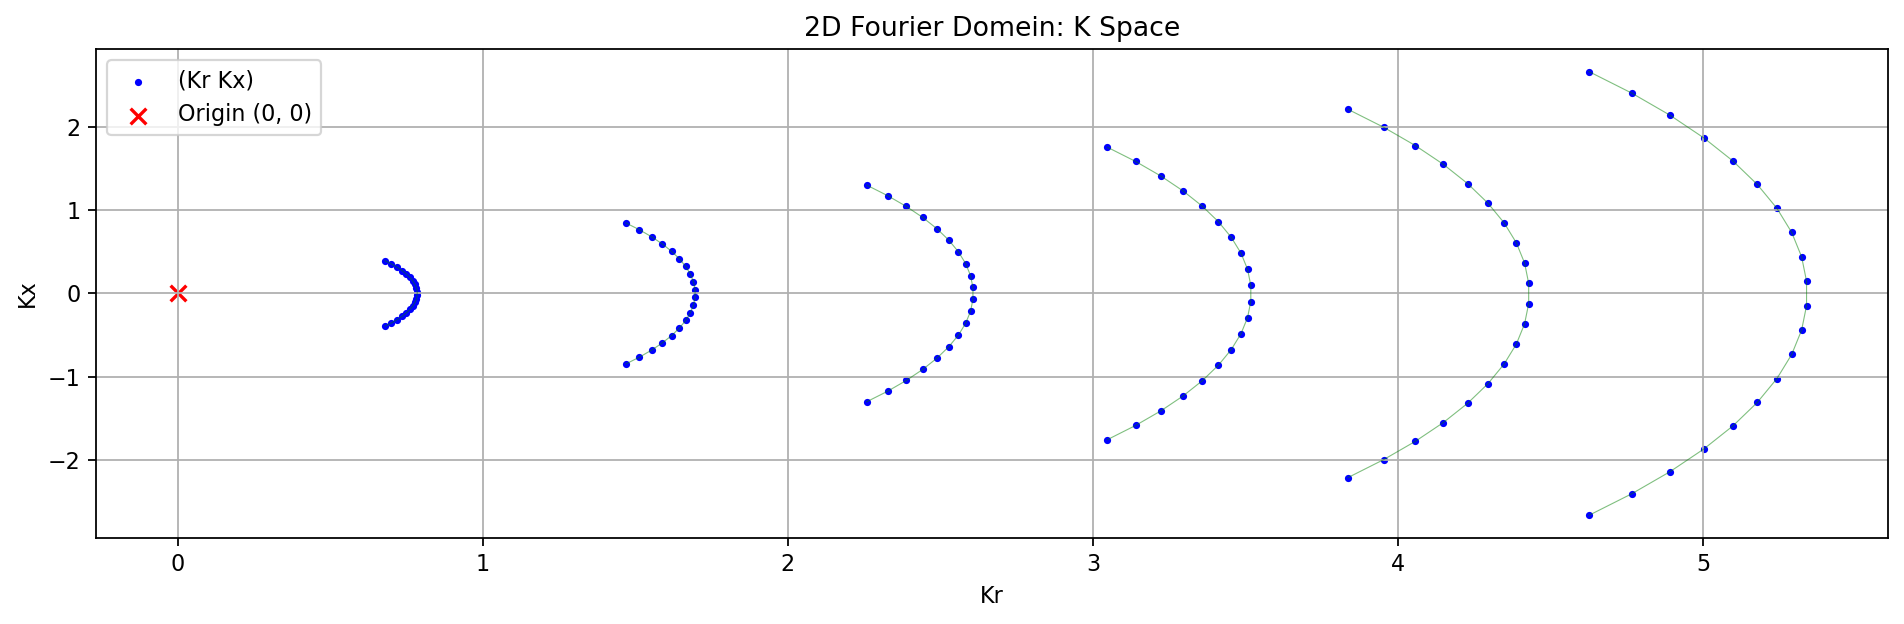

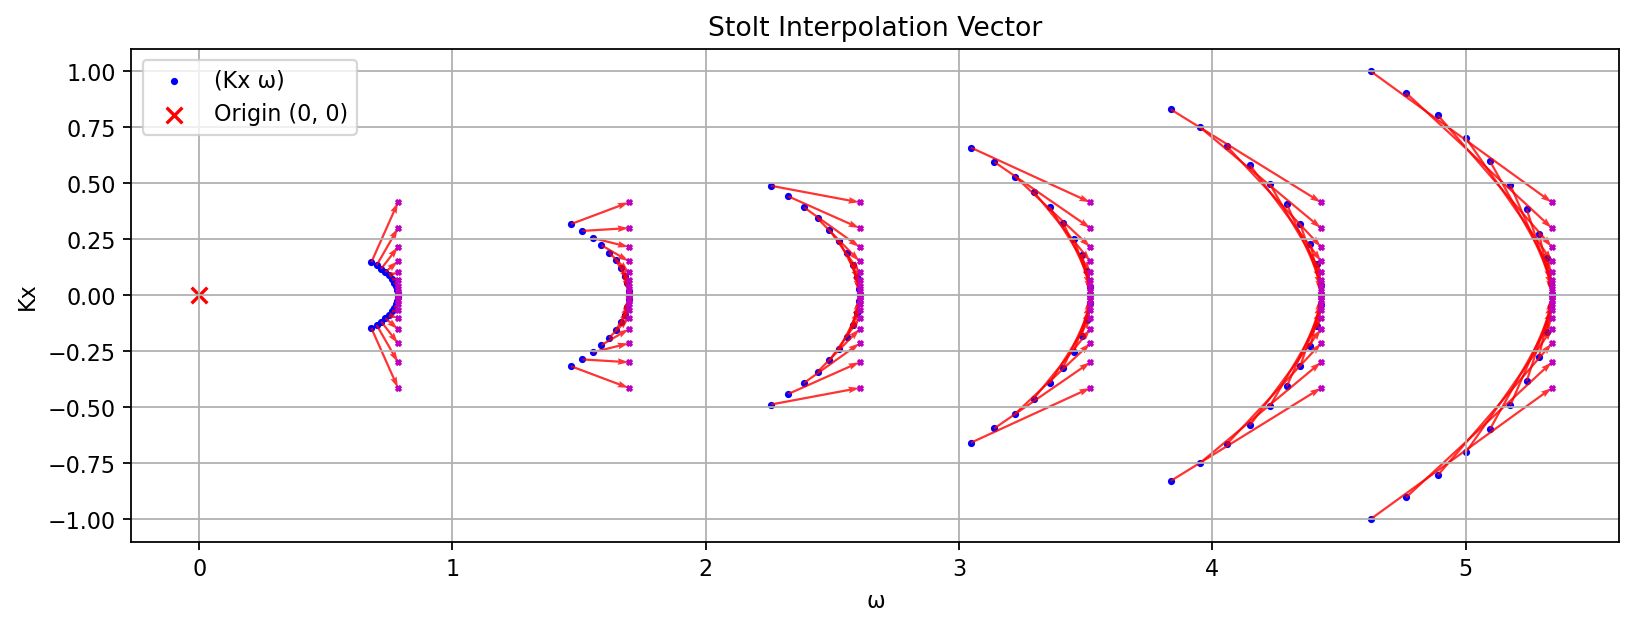

In [13]:
# sample data
NUM_PULSE = 6
NUM_SAMPLE = 20

pulse_range = np.linspace(np.pi/3, np.pi*2/3, NUM_SAMPLE)
omega_s = np.linspace(np.pi/4, np.pi * 1.7, NUM_PULSE)

# Cartesian to Polar
k_rx = np.stack([
 omega * np.array([np.sin(pulse_range), np.cos(pulse_range)])
for omega in omega_s], axis=0
)

# plot
plt.figure(figsize=(12, 4), dpi=160, facecolor='w', edgecolor='k')
plt.title('2D Fourier Domein: K Space')
plt.scatter(k_rx[:, 0], k_rx[:, 1], c='b', marker='o', label='(Kr Kx)', s=5)
for k_ in k_rx:
    plt.plot(k_[0], k_[1], c='g', linestyle='-', linewidth=0.5, alpha=0.5)
plt.scatter(0, 0, c='r', marker='x', label='Origin (0, 0)', s=50)
plt.grid()
plt.xlabel('Kr')
plt.ylabel('Kx')
plt.legend()
plt.tight_layout()
plt.savefig(f'{PATH_OUTPUT}/K-space_xr_sample{NUM_SAMPLE}_pulse{NUM_PULSE}.png')
plt.show();plt.clf();plt.close()

stolt_interpolated_kx = np.stack([
        stolt_interpolation(k_rx[:, 0, i_], k_rx[:, 1, i_], omega_s)
        for i_, rx in enumerate(k_rx[0,0,])
    ], axis=1)

omega_sample = np.stack(
    [omega_s] * stolt_interpolated_kx.shape[1],
    axis=1)

# plot
fig = plt.figure(figsize=(12, 4), dpi=160, facecolor='w', edgecolor='k')
ax = fig.add_subplot(111)

plt.title('Stolt Interpolation Vector')
plt.scatter(k_rx[:, 0], k_rx[:, 1]/k_rx[:, 1].max(), c='b', marker='o', label='(Kx ω)', s=5)
plt.scatter(0, 0, c='r', marker='x', label='Origin (0, 0)', s=50)

k_r = k_rx[:, 0]
k_x = k_rx[:, 1]/k_rx[:, 1].max()

for _i, _omera in enumerate(omega_s):
    for (post_x, post_y, pre_x, pre_y) in zip(
        omega_sample[_i],
        stolt_interpolated_kx[_i],
        k_r[_i],
        k_x[_i],
        ):
        u, v = post_x - pre_x, post_y - pre_y 
        ax.quiver(pre_x, pre_y, u, v, color='red',
              angles='xy', 
              scale_units ='xy', 
              scale=1, alpha=0.8, width=0.0015
              )
        # break # only one sample for visualization
    plt.scatter(omega_sample[_i], stolt_interpolated_kx[_i], 
                c='m', marker='x', s=5,)
plt.grid()
plt.xlabel('ω')
plt.ylabel('Kx')
plt.legend()
plt.savefig(f'{PATH_OUTPUT}/stolt_interpolation_vector_sample{NUM_SAMPLE}_pulse{NUM_PULSE}.png')
plt.show();plt.clf();plt.close()